In [1]:
##% imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import seaborn as sns

from popy.io_tools import *
from popy.behavior_data_tools import *
from behav_analysis_tools import *
from popy.config import COLORS

# fontsize 12
plt.rcParams.update({'font.size': 8})


In [2]:

def plot_strategy_change(dates, reward_rates, selected_target):
    monkeys = dates.keys()

    # plot
    fig, axs = plt.subplots(2, len(monkeys), figsize=(4*len(monkeys), 5))

    for i, monkey in enumerate(monkeys):
        # plot data
        axs[0, i].plot(dates[monkey], reward_rates[monkey], 'o', color='k')
        for target in [1, 2, 3]:
            axs[1, i].plot(dates[monkey], selected_target[monkey][target], marker='o', alpha=.5, label=f'target {target}')

        # plot settings
        ax = axs[0, i]
        ax.set_title(monkey)
        ax.axhline(.25, color='gray', linestyle='--')
        ax.axhline(.7, color='gray', linestyle='--')
        ax.set_ylabel('avg. reward earned')
        ax.set_ylim(.20, .75)
        # set xtick density for every 3 months, formatted as 'YY-MM'
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
        for tick in ax.get_xticklabels():
            tick.set_rotation(20)
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.set_xlabel('date (yy-mm)')

        ax = axs[1, i]
        ax.set_title(monkey)
        ax.axhline(1/3, color='gray', linestyle='--')
        ax.set_ylim(-0, .8)
        ax.set_ylabel('percentage of selection (%)')
        ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))
        for tick in ax.get_xticklabels():
            tick.set_rotation(20)
        ax.legend()
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.set_xlabel('date (yy-mm)')

    # legend
    plt.tight_layout()
    plt.show()


def get_reward_rate_and_selected_target(behav_all_original):
    behav_all = behav_all_original.copy()
    def conv_time(t):
        dd, mm, yy = t[:2], t[2:4], t[4:6]
        date_time = np.datetime64(f'20{yy}-{mm}-{dd}')
        return date_time
        
    monkeys = behav_all.monkey.unique()
    dates = {monkey: [] for monkey in monkeys}
    reward_rates = {monkey: [] for monkey in monkeys}
    selected_target = {monkey: {1: [], 2: [], 3: []} for monkey in monkeys}

    for monkey in monkeys:
        behav_all_monkey = behav_all.loc[behav_all.monkey == monkey]
        behav_all_monkey = behav_all_monkey.sort_values('date_of_recording')

        # get measurement dates
        dates_temp = behav_all_monkey.session.unique()
        dates[monkey] = [conv_time(t) for t in dates_temp]

        # get average reward rate and selected target
        for i, session in enumerate(behav_all_monkey.session.unique()):
            session_data = behav_all_monkey.loc[behav_all_monkey.session == session]
            
            # get average reward rate
            reward_rates[monkey].append(np.mean(session_data.feedback.values))

            # get percent of target selection
            for target in [1, 2, 3]:
                avg_selection = np.mean(session_data.target == target)
                selected_target[monkey][target].append(np.mean(session_data.target == target))

    return dates, reward_rates, selected_target


In [3]:
# load all session data, remove those labeled as invalid
behav = load_behavior()

#behav = drop_time_fields(behav)
behav = add_switch_info(behav)
behav = add_trial_in_block(behav)
behav = add_date_of_recordig(behav)
behav = drop_time_fields(behav)
behav['if_best_target'] = behav['target'] == behav['best_target']

behav

,date_of_recording,monkey,session,trial_id,block_id,best_target,target,feedback,switch,trial_id_in_block,if_best_target
0,2020-07-01,ka,010720,0,0,2,3.0,1.0,NaN,0,False
1,2020-07-01,ka,010720,1,0,2,3.0,0.0,0.0,1,False
2,2020-07-01,ka,010720,2,0,2,1.0,1.0,1.0,2,False
3,2020-07-01,ka,010720,3,0,2,1.0,0.0,0.0,3,False
4,2020-07-01,ka,010720,4,0,2,3.0,1.0,1.0,4,False
...,...,...,...,...,...,...,...,...,...,...,...
39214,2022-08-31,po,310822,419,9,2,1.0,0.0,0.0,35,False
39215,2022-08-31,po,310822,420,9,2,1.0,1.0,0.0,36,False
39216,2022-08-31,po,310822,421,9,2,1.0,1.0,0.0,37,False
39217,2022-08-31,po,310822,422,9,2,1.0,1.0,0.0,38,False


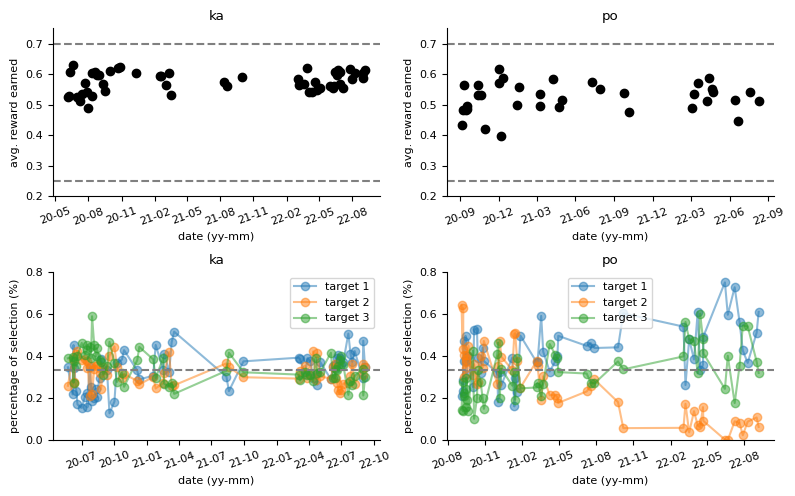

In [4]:
# get reward rates and selected target statistics over sessions
behav_monkey = add_date_of_recordig(behav)
dates, reward_rates, selected_target = get_reward_rate_and_selected_target(behav_monkey)

# plot strategy change
plot_strategy_change(dates, reward_rates, selected_target)